In [3]:
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron, SGDClassifier, RidgeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score, train_test_split, HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

### Preprocessing

In [33]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])

Based on discoveries of EDA, I delete some unusable featurs and transform others.

In [23]:
df['industry_code'] = df['cc_num'].astype(str).apply(lambda x: x[0:1]).astype(int)
df['age'] = (pd.to_datetime('today') - pd.to_datetime(df['dob'])).dt.days/365.25 
df.drop(columns=['first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city', 'job'
                 'merchant'], inplace=True)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='is_fraud'), df['is_fraud'], test_size=0.25, random_state=1)

In [27]:
X_train['trans_date_trans_time'] = (X_train['trans_date_trans_time'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')

ct1 = ColumnTransformer(
    [
        ("text_preprocess", OneHotEncoder(drop='first', sparse_output=False, dtype=bool), ['category', 'gender', 'job', 'state'])
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas') 
ct2 = ColumnTransformer(
    [
     ("num_preprocess", StandardScaler(), ['trans_date_trans_time', 'amt', 'city_pop', 'age'])
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

X_train = ct1.fit_transform(X_train)
X_train = ct2.fit_transform(X_train)
'''
X_train = X_train[['zip', 'amt', 'state']]
ct3 = ColumnTransformer(
    [
        ("text_preprocess", OneHotEncoder(drop='first', sparse_output=False, dtype=bool), ['state'])
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas') 
X_train = ct3.fit_transform(X_train)'''


'\nX_train = X_train[[\'zip\', \'amt\', \'state\']]\nct3 = ColumnTransformer(\n    [\n        ("text_preprocess", OneHotEncoder(drop=\'first\', sparse_output=False, dtype=bool), [\'state\'])\n    ],\n    remainder=\'passthrough\', verbose_feature_names_out=False).set_output(transform=\'pandas\') \nX_train = ct3.fit_transform(X_train)'

In [28]:
print(X_train.shape)
X_train.info()

(972506, 562)
<class 'pandas.core.frame.DataFrame'>
Index: 972506 entries, 167764 to 128037
Columns: 562 entries, trans_date_trans_time to industry_code
dtypes: bool(557), float64(4), int32(1)
memory usage: 557.4 MB


In [31]:
pca = PCA(n_components=0.95, copy=False)
#pca.fit_transform(X_train)
X_train = pd.DataFrame(pca.fit_transform(X_train))
print(X_train.shape)
X_train.info()
#99% (972506, 713) 5.2 GB
#95% (972506, 396) 2.9 GB

(972506, 199)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972506 entries, 0 to 972505
Columns: 199 entries, 0 to 198
dtypes: float64(199)
memory usage: 1.4 GB


scale before test


2. Transform
3. Test
4. Generate
5. Test
6. Select
7. Test, test learning
8. Imbalance
9. Test, test learning

### Feature generation

In [18]:
def evaluate(X, y):
    models = dict()
    
    models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
    #models['SVC'] = SVC(class_weight='balanced', random_state=1)
    models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
    models['Nearest Neighbor'] = KNeighborsClassifier(3)
    models['Naive Bayes'] = GaussianNB()
    models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
    models['MLPC'] = MLPClassifier(random_state=1)

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=1)
    
    names, res = [], []

    for name, model in models.items():
        print('         ', name)
        scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=5)
        print(scores)
        res.append(scores)
        names.append(name)

    plt.figure(figsize=(10, 8))
    plt.boxplot(res, labels=names, showmeans=True)
    plt.grid()
    plt.xticks(rotation=35);

In [ ]:
evaluate(X_train, y_train)

          Logistic Regression
[0.88666955 0.88272554 0.88600059 0.88344533 0.88702886 0.88968751
 0.88425252 0.8828695  0.88395432 0.88476152 0.88785205 0.88162529
 0.88347618 0.88944016 0.88261243 0.88455646 0.88735276 0.88375895
 0.88513684 0.88602115 0.88566184 0.88640161 0.88377952 0.88314199
 0.8866484  0.88911168 0.88494661 0.88638619 0.88124483 0.88387206
 0.88310146 0.88439648 0.88609827 0.88492604 0.88559956 0.88251535
 0.88474609 0.8828695  0.88762012 0.88827307 0.88191381 0.88630393
 0.88602115 0.88407772 0.8874813  0.88659757 0.88240677 0.88409828
 0.88466383 0.8867358 ]
          SGD
[0.965733   0.95251438 0.96487936 0.96470969 0.95556321 0.97028822
 0.95218019 0.94401571 0.96103876 0.95299767 0.94315226 0.94633447
 0.95923414 0.95293083 0.96324955 0.96277673 0.95683313 0.95954777
 0.96084339 0.95861718 0.96360449 0.96528553 0.95275089 0.95664804
 0.94120853 0.96575871 0.95200025 0.96175855 0.95370718 0.95475602
 0.96070992 0.95651436 0.95634984 0.94613395 0.95973285 0.963

C:\Users\dfskl\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\dfskl\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\dfskl\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dfskl\anaconda3\Lib\site-packages\sklearn\naive_bayes.py", line 263, in fit
    return self._partial_fit

[0.61612734 0.63155973        nan 0.64860849 0.62927697 0.63183926
 0.62412533 0.65136426 0.62581169 0.63376538 0.62159258 0.62861373
 0.64172421 0.65171387 0.62360605 0.63244594 0.63430008 0.63267027
 0.63752886 0.62517416 0.63889317 0.62783739 0.62233099 0.63135408
 0.64488614 0.64302681 0.61193516 0.64227433 0.63035151 0.64293757
 0.63729422 0.61752382 0.63101475 0.64033604 0.63590933 0.64010653
 0.63606871 0.63071655 0.62395052 0.63941059 0.63728394 0.63483478
 0.62669087 0.63093763 0.63140549 0.6306002  0.65158534 0.63776022
 0.62031558 0.62656747]
          Decision Tree
[0.99612857 0.9961337  0.99609257 0.99607714 0.99616969 0.99607716
 0.99596403 0.99616454 0.99589719 0.99626223 0.99604631 0.99596917
 0.99630336 0.99618511 0.9960103  0.99617999 0.99609771 0.99603601
 0.99619025 0.99612855 0.9959075  0.99596403 0.9961337  0.99609257
 0.99616454 0.99600518 0.99610799 0.99623652 0.99595375 0.99608742
 0.99614914 0.99602573 0.9961594  0.99602573 0.99591262 0.99605145
 0.99612855 0.

          Logistic Regression
          SGD
          Nearest Neighbor
          Naive Bayes
          Decision Tree
          Random Forest
          MLPC


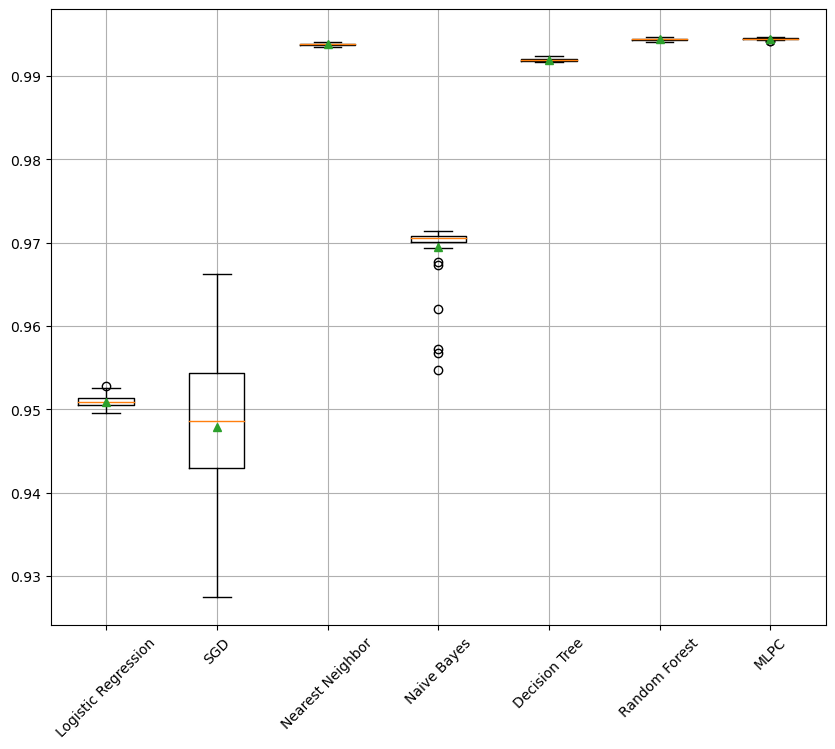

In [11]:
evaluate(X_train, y_train)

### Feature selection

### Handling imbalanced data